# ARIM-Academy：　基礎編　Scikit-learn（探索的データ分析：Exploratory Data Analysis）

**対象読者：** Python基礎文法（変数、リスト、for文、関数の呼び出し）を理解している方。`Scikit-learn-1_EDA.ipynb`（住宅価格編）を先に学習していれば、コードの構成が共通していることが分かりやすくなります。

**前提知識：** 概要統計・箱ひげ図・ペアプロット・相関係数・単回帰の基本操作は住宅価格編と同じ手順です。本編ではデータセットだけを実際の研究データ（大気腐食）に差し替えています。

**動作環境：** Python 3.10以降 / pandas 2.x / numpy 1.26以降 / matplotlib 3.8以降 / seaborn 0.12以降。Google Colabの標準環境であれば満たされます。

**版・ライセンス：** 本ノートブックのコード部分はMITライセンスで提供します。

---

## 本編の目標
この演習では、『**大気腐食データセット**』を活用し、探索的データ分析（Exploratory Data Analysis, EDA）の基礎を習得することを目的としています。

> **本編と住宅価格編の関係：** ここまでの2編（`Scikit-learn-1_EDA.ipynb`・`Scikit-learn-2_ML.ipynb`）では、架空の教材用データセット（Japan Housing）を使ってきました。本編からの2つのノートブックでは、**物質・材料研究機構（NIMS）における実際の研究成果**である大気腐食データを題材に、**まったく同じコードの構成・同じscikit-learnの使い方**が、題材（住宅価格 → 金属腐食）が変わっても通用することを確認します。コードの「型」を一度覚えれば、データが変わっても応用できる、という点が本編のポイントです。

### EDAの目的
EDAの主な目的は以下の通りです。

* **データの理解:** データセットの構造や変数の意味、データの分布を把握します。
* **データの可視化:** グラフや図を用いて、データの分布、パターン、異常値を視覚的に表現します。
* **変数間の関係性の探索:** 相関分析やクロス集計などにより、変数間の関係性を明らかにします。
* **データ前処理への示唆:** 欠損値の処理や外れ値の検出、特徴量エンジニアリングに役立つ示唆を得ます。

### EDAの重要性
EDAはデータ分析とそれに続く機械学習モデルの検討において不可欠なステップです。EDAを通じて得られた知見は、以下の点で重要な役割を果たします。

* **適切なモデル選択:** データの特性に基づき、最適な機械学習モデルを選択できます。
* **特徴量エンジニアリング:** 新たな特徴量の作成や既存特徴量の加工により、モデルの性能を向上させます。
* **データ品質の向上:** 欠損値や外れ値を検出し、適切に処理することで、モデルの精度を向上させます。

### 本編における内容　`（　）内は本ノートブックのコードでの実施範囲`
* **データの理解と準備**（実施：`Month`列の削除。欠損値は検証の結果ゼロ件でした。外れ値の系統的な検出・除去は行いません）: データセットの構造や分布を把握します。
* **特徴量の探索と相関分析**（実施：概要統計・箱ひげ図・ペアプロット・ピアソン相関係数・ヒートマップ）: 気象因子を特徴量とするこのデータセットを通じ、各特徴量の分布や相関関係を探索します。
* **データの可視化**（実施：ヒストグラム・散布図・箱ひげ図）: データを視覚的に表現する手法を習得します。
* **データの解釈と洞察の獲得**: 特徴量間の関係性やデータパターンを分析し、そこから得られる洞察を解釈する力を養います。
---

## データセット
**大気腐食データセット**は、日本の6地点における月次の標準試験片の腐食量データと、気温、風速、降水量、湿度など、さまざまな気象データを組み合わせたものです。このデータセットは、松波らによる『海塩輸送シミュレーションと気象情報を用いた機械学習に基づく大気腐食量評価モデル開発と高精細腐食環境地図の作成』[1] に基づいていますが、本講義用にアレンジされたもので、論文で使用されたデータセットとは異なります。

[1] 松波 成行, 柳生 進二郎, 篠原 正, 片山 英樹, 須藤 仁, 服部 康男, 平口 博丸　"海塩輸送シミュレーションと気象情報を用いた機械学習に基づく大気腐食量評価モデル開発と高精細腐食環境地図の作成", 土木学会論文集A1（構造・地震工学） Vol.75, p141-160(2019) https://www.jstage.jst.go.jp/article/jscejseee/75/2/75_141/_article/-char/ja/

> データセットの実際の構造：71件のレコードは、**6地点（Naha, Miyakojima, Fukuoka, Shizuoka, Tsukuba, Choshi）×約12か月分**（那覇のみ11か月分）です。地点名はデータフレームの**インデックス**（行ラベル）として格納されており、モデルの入力（説明変数）としては使われません。この点は、後編（`Scikit-learn-4_ML.ipynb`）でモデルの汎化性能を考えるときに重要な意味を持ちます。

### 腐食観測量
1. **Corrosion**: 腐食速度 （g/m2/y）

### 気象変数
気象データは気象庁の観測値を基にしており、以下の16変数が含まれます。これらの変数は、説明変数として使用します。

1. **AT** : 平均気温（℃）  
2. **HAT** : 日最高気温の平均（℃）  
3. **LAT** : 日最低気温の平均（℃）  
4. **HT** : 最高気温（℃）  
5. **LT** : 最低気温（℃）  
6. **Rain** : 降水量の合計（mm）  
7. **Mrain** : 日降水量の最大（mm）  
8. **Sun** : 日照時間（時間）  
9. **Msnow** : 最深積雪（cm）  
10. **Snow** : 降雪量合計（cm）  
11. **AW** : 平均風速（m/s）  
12. **MW** : 最大風速（m/s）  
13. **PMW** : 最大瞬間風速（m/s）  
14. **Vap** : 平均蒸気圧（hPa）  
15. **Hum** : 平均湿度（％）  
16. **Lhum** : 最小相対湿度（％）

> **表記の注意：** 変数名の大文字・小文字はCSVファイルの列名と完全に一致させています（`Mrain`・`Msnow`・`Lhum`など）。`df['LHum']`のように大文字・小文字を実際の列名と違えて書くと`KeyError`になりますので、コードを書くときは実際の列名（`df.columns`で確認できます）をそのまま使ってください。

---

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
!git clone https://github.com/ARIM-Academy/Advanced_Tutorial_1.git
%cd Advanced_Tutorial_1

# 1. データセットの読み込みと前処理

### ライブラリのインポート
この演習で使用するPythonライブラリをimportします。なお、機械学習に関連するscikit-learnライブラリは、後半で別途importします。

In [1]:
#ライブラリ
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### サンプルファイルの読み込み

`pandas`ライブラリの`read_csv()`関数は、CSVファイルを読み込んで`pandas`の`DataFrame`形式に変換するための関数です。このセクションでは、[data]フォルダ内に保存されている`corrosin_data.csv`ファイルを`DataFrame`として読み込み、その結果を`df`という変数に格納します。`index_col=0`を指定しているのは、1列目（地点名`Place`）を行インデックスとして扱うためです。

In [2]:
#データセットの読み込み
df = pd.read_csv('data/corrosin_data.csv', index_col=0)
df

,Month,AT,HAT,LAT,HT,LT,Rain,Mrain,Sun,Msnow,Snow,AW,MW,PMW,Vap,Hum,Lhum,Corrosion
Place,,,,,,,,,,,,,,,,,,
Naha,1,28.3,26.0,31.1,33.6,23.4,178.0,79.0,206.5,0,0,6.0,14.5,20.9,28.5,74,43,674
Naha,2,25.3,23.5,27.7,30.8,19.9,200.0,118.0,129.7,0,0,7.3,22.0,33.6,23.4,72,40,2606
Naha,3,21.3,19.1,23.8,28.5,13.9,121.0,79.0,120.0,0,0,5.0,12.7,20.6,17.4,66,34,546
Naha,4,17.3,15.0,19.6,23.6,10.3,130.0,52.0,89.4,0,0,5.4,14.5,21.5,12.7,64,37,704
Naha,5,16.8,14.1,19.8,23.5,10.6,66.0,36.5,145.4,0,0,5.0,13.1,20.2,11.8,61,32,620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Choshi,8,14.3,10.8,17.6,21.3,3.5,70.5,13.5,232.2,0,0,5.4,15.6,19.2,11.0,67,22,567
Choshi,9,18.2,15.2,21.6,26.1,12.2,151.0,56.5,257.0,0,0,5.7,21.1,26.8,16.6,78,30,541
Choshi,10,21.1,18.9,24.0,27.3,17.1,177.5,56.0,172.3,0,0,4.5,14.3,19.4,22.3,89,46,830


### 不必要な特徴量の削除
pandasライブラリではデータフレームから特定の行や列を削除する操作で`drop()`メソッドを使います。ここではデータフレームdfから観測月を表す`Month`（1〜12の整数）列を削除します。

> **なぜ削除するのか：** `Month`は1〜12の整数ですが、これをそのまま数値の説明変数として使うと「12月」と「1月」が数値上は遠い（11の差）のに、季節としては隣り合っている、という周期性をモデルが正しく扱えません。気温や日照時間など、他の気象変数がすでに季節の情報を暗に含んでいるため、本ノートブックでは`Month`をそのまま特徴量として使わず削除します。（`sin`・`cos`変換で周期性を保ったまま数値化する方法もありますが、本ノートブックでは扱いません。）

In [3]:
#　記述子（特徴量）の削除
df = df.drop(['Month'],axis = 1)
df

,AT,HAT,LAT,HT,LT,Rain,Mrain,Sun,Msnow,Snow,AW,MW,PMW,Vap,Hum,Lhum,Corrosion
Place,,,,,,,,,,,,,,,,,
Naha,28.3,26.0,31.1,33.6,23.4,178.0,79.0,206.5,0,0,6.0,14.5,20.9,28.5,74,43,674
Naha,25.3,23.5,27.7,30.8,19.9,200.0,118.0,129.7,0,0,7.3,22.0,33.6,23.4,72,40,2606
Naha,21.3,19.1,23.8,28.5,13.9,121.0,79.0,120.0,0,0,5.0,12.7,20.6,17.4,66,34,546
Naha,17.3,15.0,19.6,23.6,10.3,130.0,52.0,89.4,0,0,5.4,14.5,21.5,12.7,64,37,704
Naha,16.8,14.1,19.8,23.5,10.6,66.0,36.5,145.4,0,0,5.0,13.1,20.2,11.8,61,32,620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Choshi,14.3,10.8,17.6,21.3,3.5,70.5,13.5,232.2,0,0,5.4,15.6,19.2,11.0,67,22,567
Choshi,18.2,15.2,21.6,26.1,12.2,151.0,56.5,257.0,0,0,5.7,21.1,26.8,16.6,78,30,541
Choshi,21.1,18.9,24.0,27.3,17.1,177.5,56.0,172.3,0,0,4.5,14.3,19.4,22.3,89,46,830


# 2. データの探索的分析 (EDA)

本ノートブックのコードでは、以下の①〜④を実施します。

#### ①概要統計量の算出（数値＋箱ひげ図による可視化）
* **目的:** データの全体的な傾向を把握します。数値だけでは分かりにくいため、箱ひげ図でも可視化します。
* **手法:** 平均値、中央値、標準偏差、最小値、最大値などを計算し、さらに箱ひげ図として可視化します。
* **ツール:** pandasの`describe()`メソッド、seabornの`boxplot()`関数

#### ②ペアプロットの作成
* **目的:** 数値型変数間の関係性を散布図行列として可視化します。
* **手法:** 全変数、および絞り込んだ変数リストについて散布図行列を作成します。
* **ツール:** seabornの`pairplot()`関数

#### ③ピアソン相関係数の計算
* **目的:** 変数間の相関関係を数値として定量的に評価します。
* **手法:** 全数値変数間の相関係数行列を計算します。
* **ツール:** pandasの`corr()`メソッド

#### ④相関係数のヒートマップ
* **目的:** 相関係数行列を色で表現し、変数間の関係性を直感的に把握します。
* **手法:** 相関行列をヒートマップとして可視化します。
* **ツール:** seabornの`heatmap()`関数

> **注記:** ヒストグラムや散布図を使った個別の特徴量の可視化は、次の「3. データの可視化」で扱います。箱ひげ図は①で使用しますが、バイオリンプロットは本ノートブックでは使用しません。

3つそれぞれのデータ分析についてみてみましょう

### ①概要統計
概要統計（Descriptive Statistics）は、データセットの要約統計量を計算することで、データの特徴や分布を理解する手法です。出力される指標は、データ数（カウント）、平均、標準偏差、最小値、最大値、四分位数（および中央値）です。

pandasライブラリに含まれている`describe()`メソッドを使うとデータセットの概要統計を簡単に取得することができます。具体的には、`describe()`関数は以下の統計情報を計算します。

1. **カウント（Count）:** データの非欠損値の数を示します。
2. **平均（Mean）:** データの平均値を示します。
3. **標準偏差（Standard Deviation）:** データのばらつきの尺度を示します。
4. **最小値（Minimum）:** データの最小値を示します。
5. **第一四分位数（25th Percentile）:** データの下位25%の値を示します。
6. **中央値（Median）:** データの中央値（50thパーセンタイル）を示します。
7. **第三四分位数（75th Percentile）:** データの上位25%の値を示します。
8. **最大値（Maximum）:** データの最大値を示します。

> このデータセットは71件と少なく、6地点×約12か月分の観測しかありません。`count`が71（一部の列で70）になっていることを確認しておきましょう。

In [4]:
#概要統計
df.describe()

,AT,HAT,LAT,HT,LT,Rain,Mrain,Sun,Msnow,Snow,AW,MW,PMW,Vap,Hum,Lhum,Corrosion
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,18.357746,15.057746,22.080282,27.078873,10.543662,168.260563,56.866197,168.360563,0.394366,0.605634,3.901408,13.028169,21.056338,17.240845,71.873239,31.000000,731.183099
std,7.366113,8.254188,6.804003,6.015193,8.945306,113.671986,37.373115,48.951817,3.091365,4.755385,1.622563,5.507636,7.019010,8.491922,8.988770,14.081396,572.607852
min,2.800000,-3.600000,9.100000,14.900000,-7.700000,16.000000,7.000000,61.700000,0.000000,0.000000,1.800000,6.500000,12.400000,4.300000,53.000000,9.000000,57.000000
25%,12.950000,8.000000,17.250000,22.900000,2.400000,94.750000,29.000000,129.100000,0.000000,0.000000,2.400000,9.350000,17.300000,9.450000,64.000000,18.500000,404.500000
50%,19.300000,16.800000,23.600000,27.300000,12.100000,134.500000,47.000000,174.000000,0.000000,0.000000,3.400000,11.400000,19.300000,17.000000,72.000000,30.000000,562.000000
75%,24.550000,21.600000,27.600000,31.950000,17.550000,196.500000,76.500000,201.850000,0.000000,0.000000,5.200000,14.500000,21.500000,23.850000,79.000000,40.500000,914.000000
max,29.400000,27.300000,32.300000,37.000000,25.600000,494.000000,212.000000,280.700000,26.000000,40.000000,7.300000,33.500000,50.200000,33.400000,90.000000,63.000000,2799.000000


### 数値だけでは分かりにくい：箱ひげ図で可視化する（図1）
`describe()`は数値としては正確ですが、数字の羅列だけを見てもデータの分布や偏り、外れ値の有無は直感的にはつかみにくいものです。そこで、目的変数である`Corrosion`（腐食速度）を箱ひげ図（Box Plot）として可視化してみましょう。

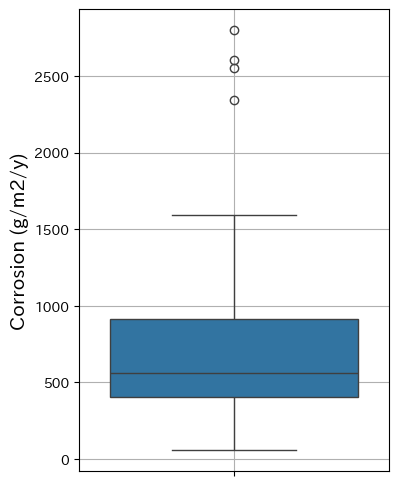

In [5]:
#腐食速度の箱ひげ図
fig, ax = plt.subplots(figsize=(4,6))

sns.boxplot(y=df['Corrosion'], ax=ax)

ax.set_ylabel('Corrosion (g/m2/y)', fontsize=14)
plt.grid()
plt.show()

上のグラフと、先ほどの`describe()`の`Corrosion`列の数値を見比べてみましょう。中央値付近に多くの点が集まる一方、上側に外れ値のような高い腐食速度の点がいくつか見えるはずです。海に近く塩害の影響を受けやすい地点（沖縄・宮古島など）で特に腐食が進みやすいことが、後ほどのペアプロットや相関分析でより詳しく確認できます。

### ②　ペアプロット（散布図行列）（図2・図3）
ペアプロット（Pair plot）は、データセット内の複数の数値変数の組み合わせに基づいた散布図行列を可視化する手法で、変数間の相関やパターンを把握することができます。

ペアプロットを作成するライブラリは幾つかありますが、Seabornライブラリの`pairplot()`メソッドは比較的に簡単にデータセット内の数値変数の組み合わせに基づいて散布図行列を作成し、各変数間の散布図やヒストグラムを表示します。

> **実行前の注意：** 次のセルは、`Corrosion`を含む全17変数（17×17＝289個）の散布図行列を描画するため、**実行にかなりの時間がかかり**、図全体も非常に小さくぎっしりと詰まって見づらくなります（住宅価格編の14変数よりもさらに変数が多いことに注意）。まずは全体像をつかむために実行し、そのあとで変数を絞り込んだ図3と見比べてみてください。

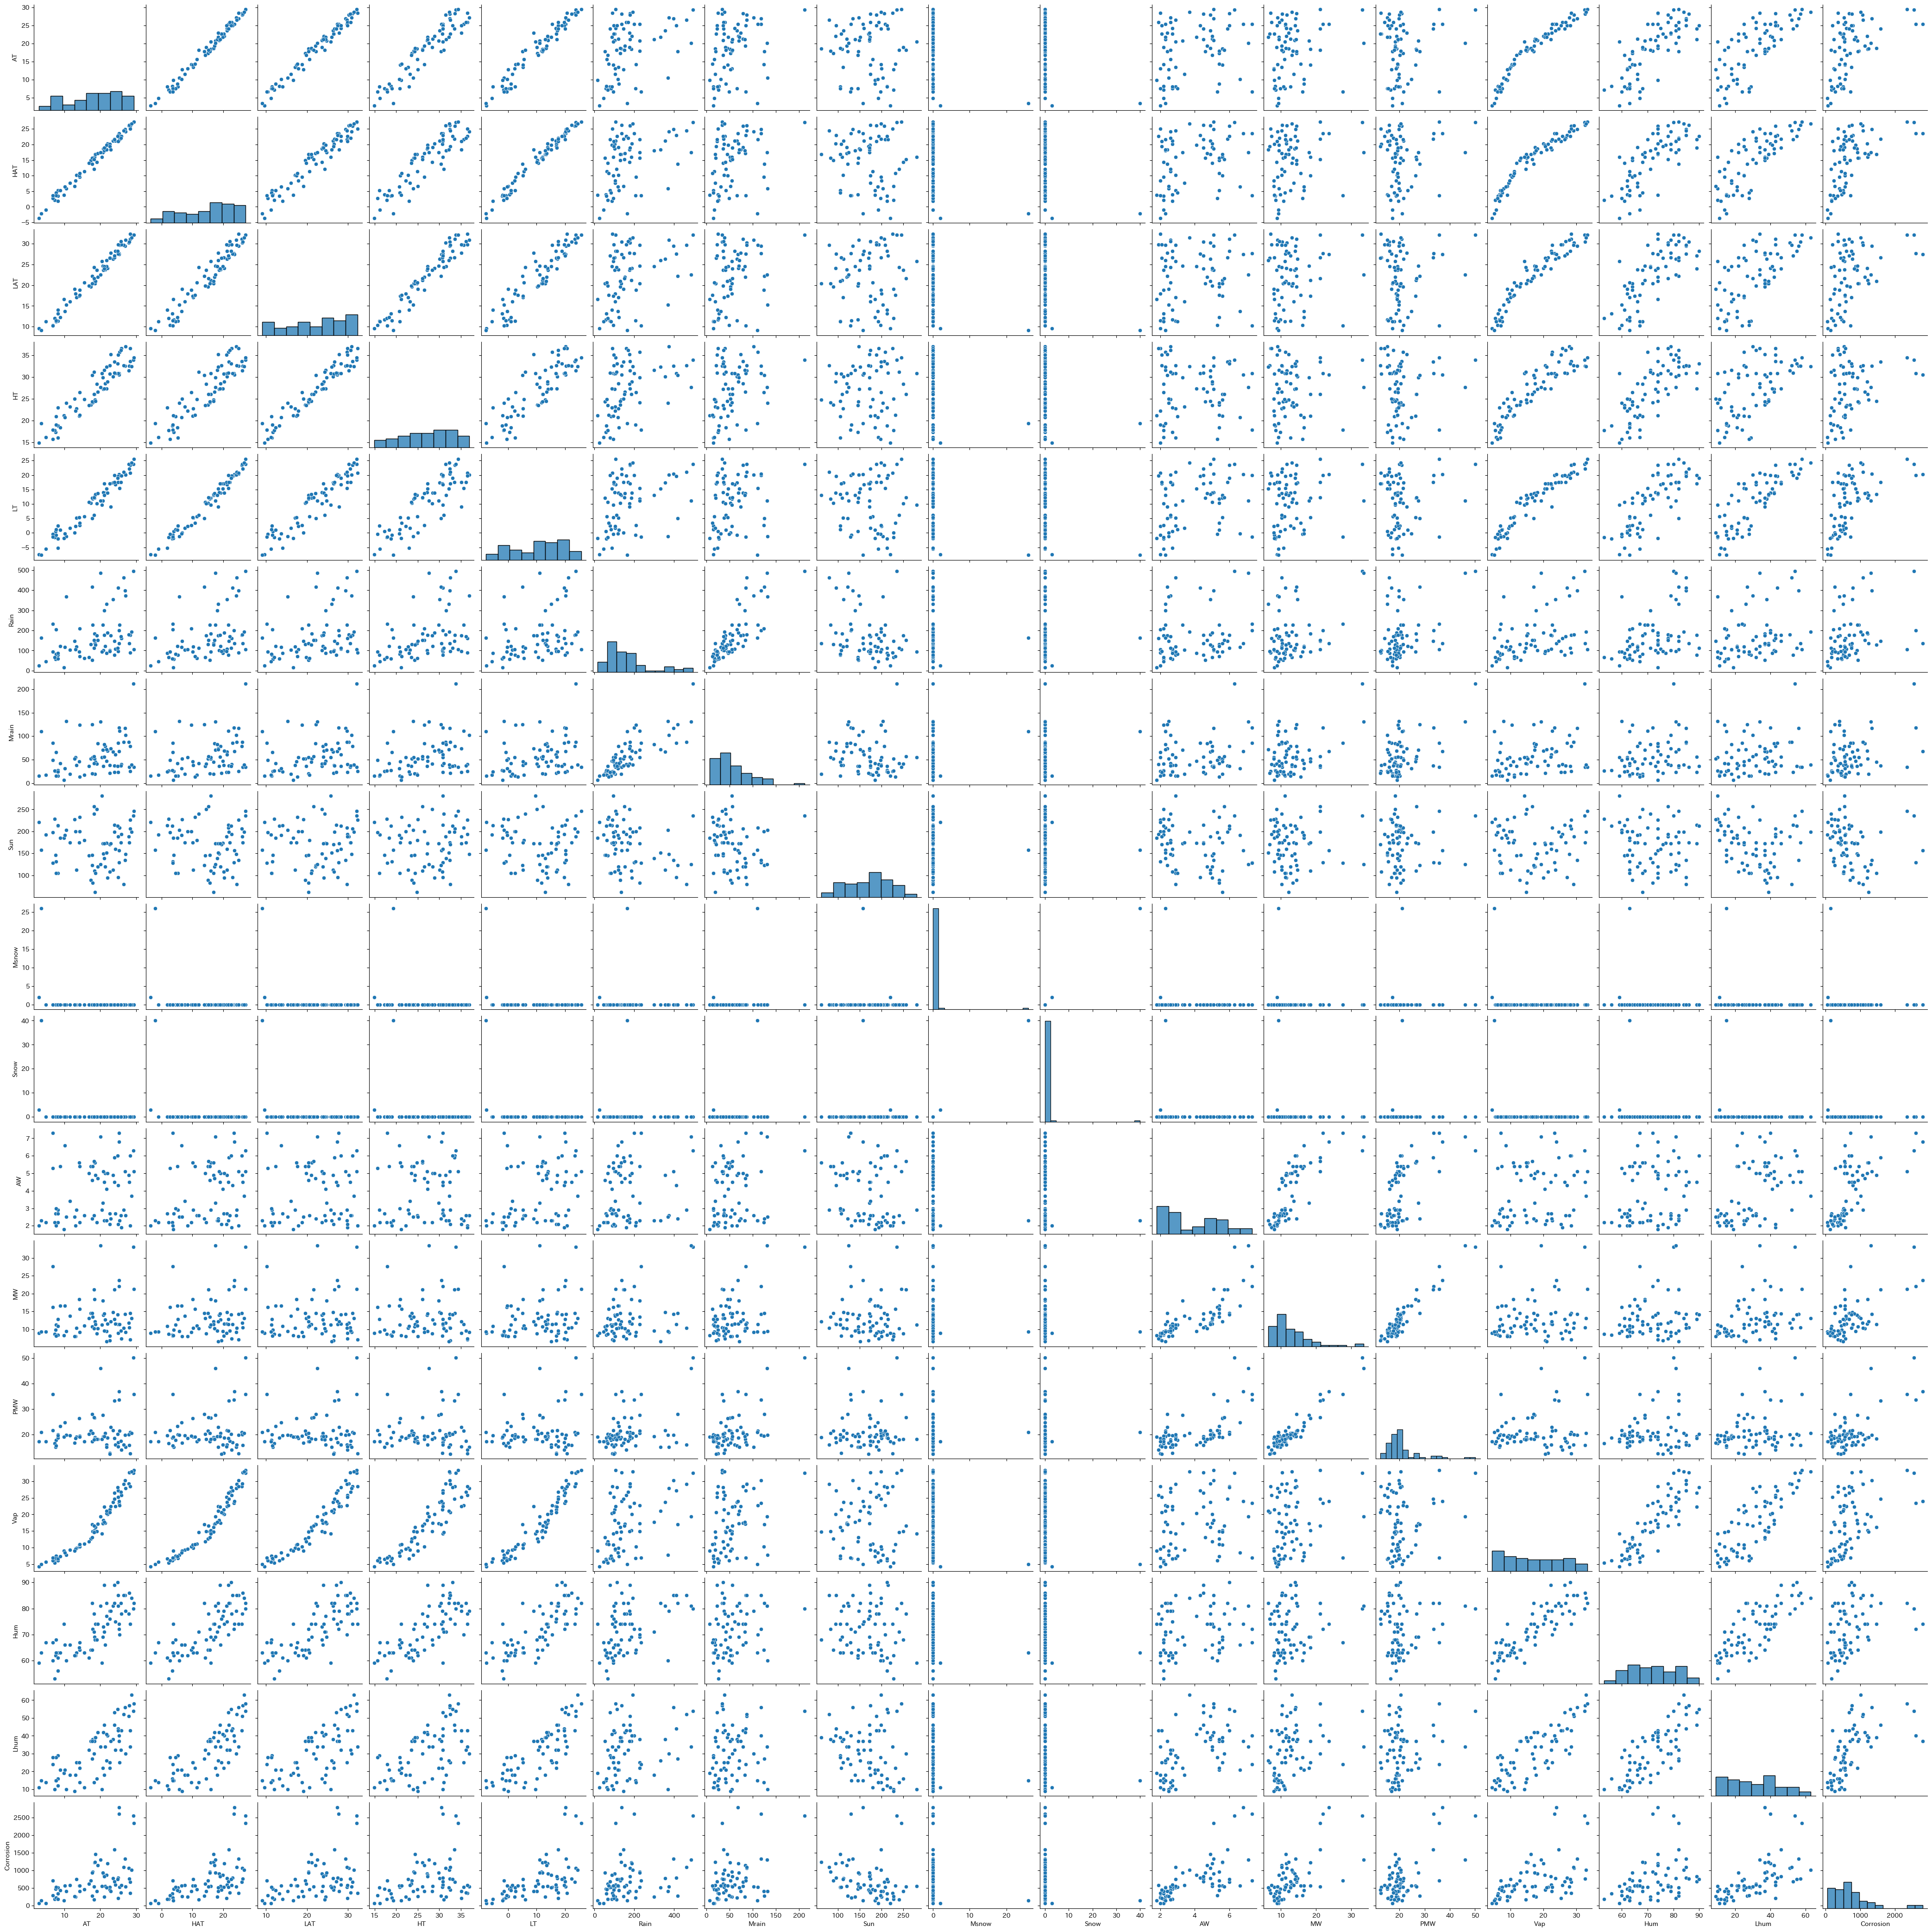

In [6]:
#　ペアプロットによる各変数間の二次元空間像
sns.pairplot(df)
plt.show()

表示させる変数名を絞り込んでみましょう。`pairplot()`のメソッドでは次のようにデータフレームの変数名を指定することで対応できます。

> **注意:** 変数名には`FEATURES`（可視化対象の特徴量リスト）という名前を使います。目的変数（`Corrosion`）を指す`TARGET`という名前と混同しないようにしましょう。

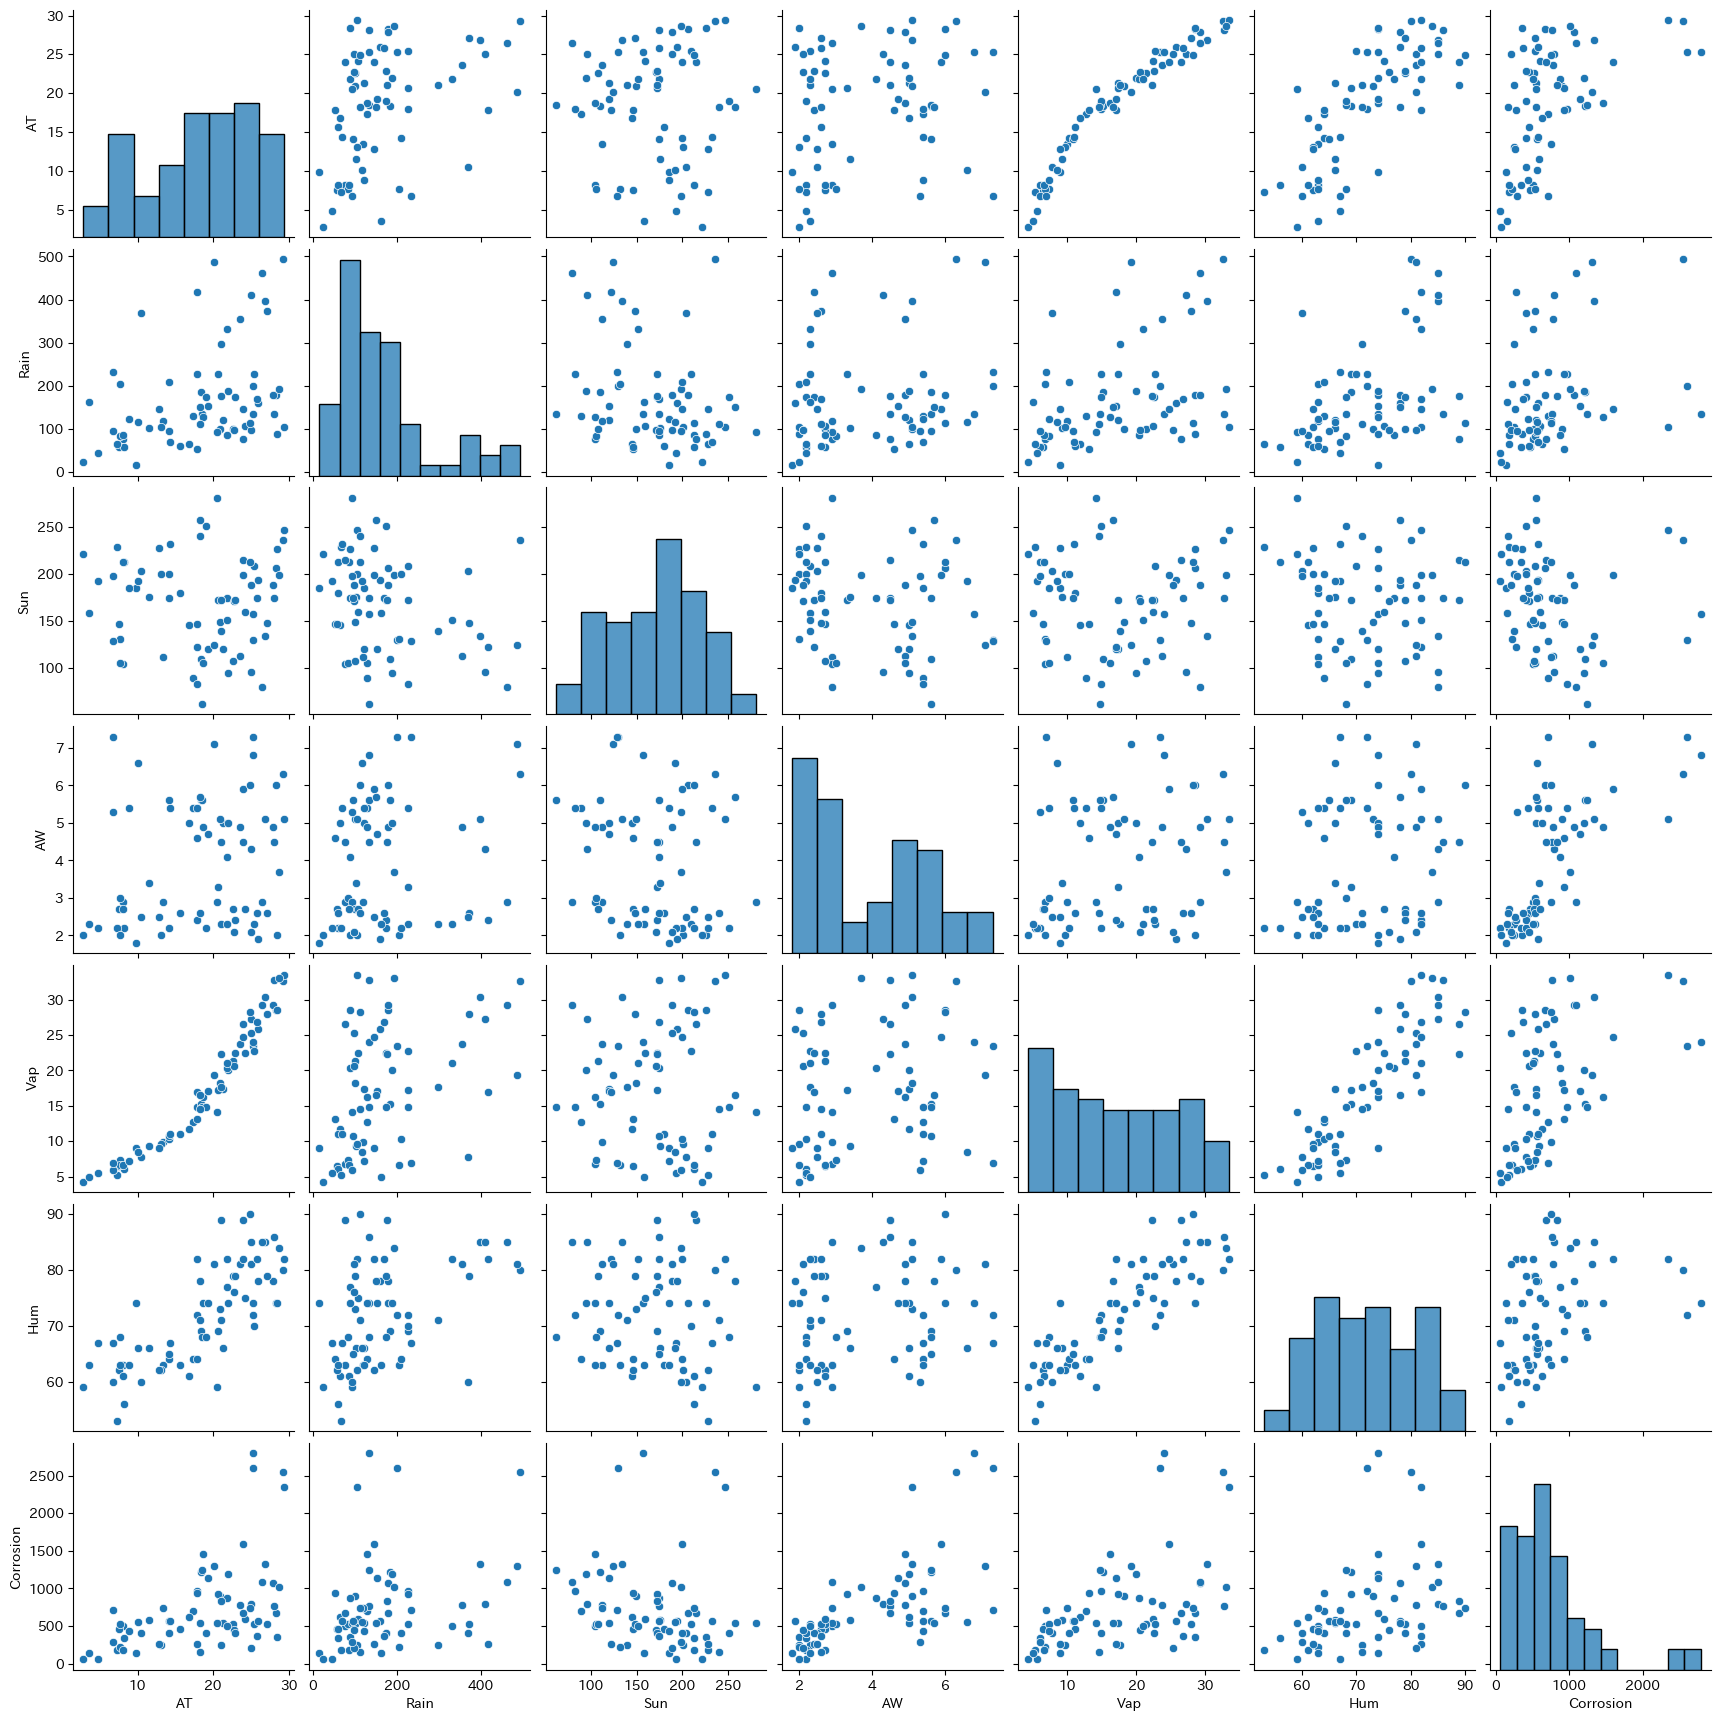

In [7]:
#　ペアプロットによる各変数間の二次元空間像（その２）
FEATURES = ['AT','Rain','Sun','AW','Vap','Hum','Corrosion']
sns.pairplot(df[FEATURES])
plt.show()

### ③ピアソン相関係数

ピアソンの相関係数は、2つの変数の間の線形関係の強さと方向を示す統計的指標です。値は-1から1の範囲を取り、以下のように解釈されます：

1：完全な正の相関（変数が同じ方向に変動）  
0：相関なし（変数間に線形関係がない）  
-1：完全な負の相関（変数が逆の方向に変動）  

相関係数の絶対値が大きいほど、2つの変数間の線形関係が強いことを示します。
pandasの`corr()`メソッドを使用すると数値データを持つ全ての列間の相関係数を計算し、相関行列として出力します。

> **注意：相関は因果関係を意味しません。** 例えばこのあと`AW`（平均風速）と`Corrosion`（腐食速度）に正の相関が見られますが、これは「風が強いこと自体が腐食の直接の原因」と断定するものではありません。風速が強い地点は海からの飛来塩分量も多い、といった共通の背景要因が存在する可能性があります。相関係数はあくまで「2変数が一緒に変動する傾向」を示す指標であり、原因と結果の関係を示すものではない点に注意してください。

In [8]:
#　相関係数
corr = df.corr()
corr

,AT,HAT,LAT,HT,LT,Rain,Mrain,Sun,Msnow,Snow,AW,MW,PMW,Vap,Hum,Lhum,Corrosion
AT,1.000000,0.992708,0.988412,0.933542,0.970636,0.381221,0.293055,-0.012393,-0.261869,-0.261411,0.227534,0.154631,0.124281,0.962473,0.765809,0.742856,0.513114
HAT,0.992708,1.000000,0.963873,0.896122,0.985858,0.384795,0.291415,-0.088417,-0.270644,-0.270154,0.302616,0.196578,0.147877,0.956568,0.768230,0.787954,0.563983
LAT,0.988412,0.963873,1.000000,0.961843,0.934699,0.361708,0.278912,0.073242,-0.246169,-0.245774,0.116437,0.087683,0.079251,0.953004,0.756036,0.673477,0.437072
HT,0.933542,0.896122,0.961843,1.000000,0.848740,0.406988,0.320879,0.089648,-0.172094,-0.171647,0.001760,0.030345,0.056243,0.896632,0.730786,0.559691,0.332105
LT,0.970636,0.985858,0.934699,0.848740,1.000000,0.337254,0.234049,-0.099407,-0.263686,-0.263251,0.318863,0.188195,0.123468,0.951370,0.770487,0.820029,0.578026
Rain,0.381221,0.384795,0.361708,0.406988,0.337254,1.000000,0.811960,-0.289397,-0.017290,-0.016999,0.156220,0.348485,0.388070,0.414962,0.435600,0.271455,0.290696
Mrain,0.293055,0.291415,0.278912,0.320879,0.234049,0.811960,1.000000,-0.108474,0.160589,0.160864,0.210707,0.421179,0.518364,0.297249,0.210510,0.165764,0.364023
Sun,-0.012393,-0.088417,0.073242,0.089648,-0.099407,-0.289397,-0.108474,1.000000,-0.015529,-0.015778,-0.202259,-0.013033,0.048703,0.008049,-0.119020,-0.224021,-0.187312
Msnow,-0.261869,-0.270644,-0.246169,-0.172094,-0.263686,-0.017290,0.160589,-0.015529,1.000000,0.999998,-0.129414,-0.088258,-0.005911,-0.187277,-0.131842,-0.149648,-0.133380
Snow,-0.261411,-0.270154,-0.245774,-0.171647,-0.263251,-0.016999,0.160864,-0.015778,0.999998,1.000000,-0.129159,-0.088096,-0.005788,-0.186947,-0.131527,-0.149337,-0.133126


### ④相関係数のヒートマップ
相関係数の数値だけでは、変数間の関係は直感的にわかりづらいものです。そこで、ヒートマップを用いて相関係数行列を可視化することで、変数間の関係性を視覚的に把握します。seabornライブラリの`heatmap()`関数は、DataFrame内の数値データの相関係数を色で表現したヒートマップを簡単に作成できます。またオプションとして`annot=True`を指定することで、各セルに相関係数の数値を表示します。

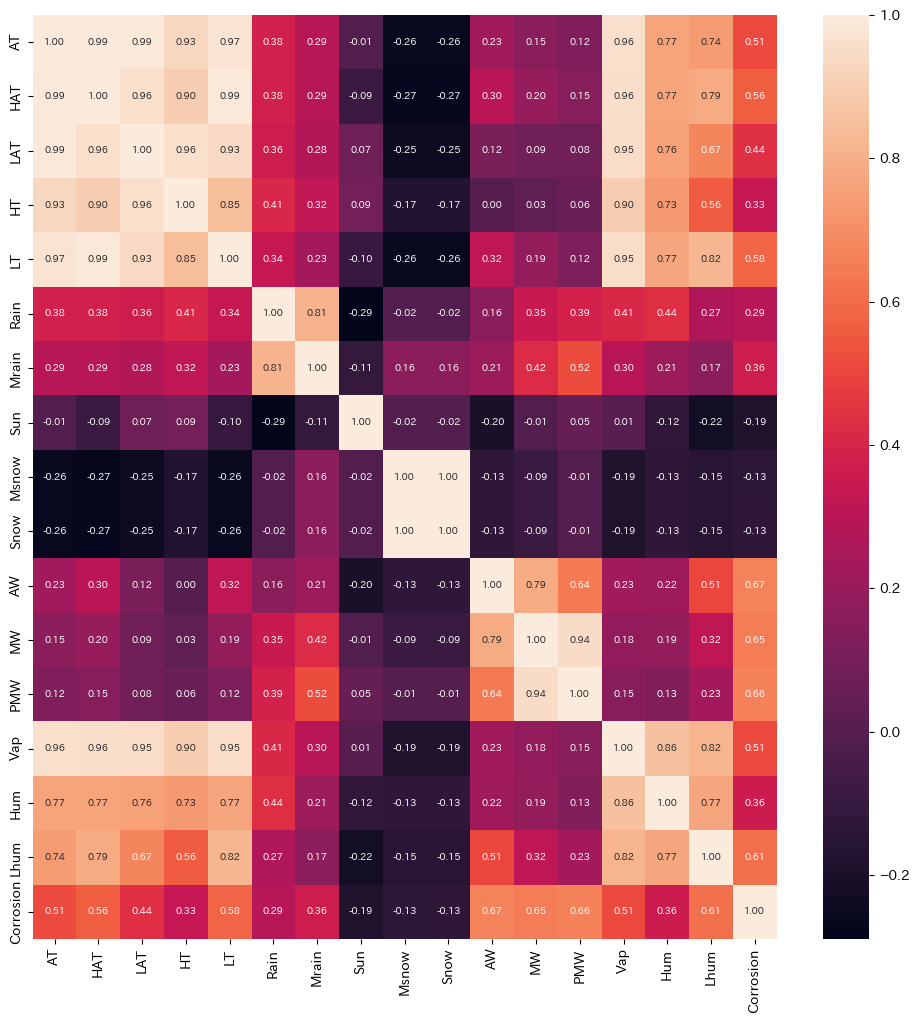

In [9]:
#相関係数をヒートマップ化する
#　注：17変数分のセルに数値を表示するため、フォントサイズを小さくして見やすくしています

plt.figure(figsize=(12,12))

sns.heatmap(corr, annot=True, fmt='.2f', annot_kws={"size": 7})
plt.show()

# 3. データの可視化
ペアプロットでは対象とするすべての相関グラフとヒストグラムを出力しました。ここでは、特に着目する特徴量のグラフについてmatplotlibを使って可視化する流れを学びます。

### 頻度分析（ヒストグラム）（図4）
大気腐食データセットにおける腐食量の分布を視覚化するヒストグラムを表示し、腐食量の頻度をみてみましょう。

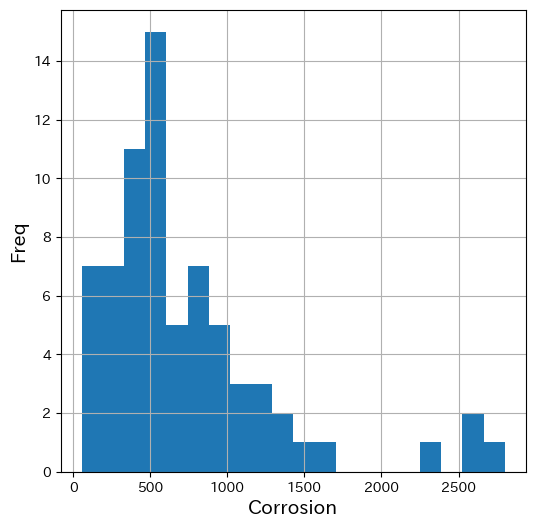

In [10]:
# 腐食量のヒストグラム
fig, ax = plt.subplots(figsize=(6,6))

#着目する変数の指定（ここでは腐食量）
X = df['Corrosion']

#ビン数は20分割
ax.hist(X, bins = 20)

#ラベル名
plt.xlabel('Corrosion', fontsize =14)
plt.ylabel('Freq', fontsize =14)

plt.grid()
plt.show()

### 相関図（図5）
大気腐食データセットを使って、腐食量 (Corrosion) と平均風速 (AW) との関係を示す散布図を作成してみましょう。

> **注記：** 以下のコードでは`X`・`y`とも二重括弧`[[列名]]`で2次元DataFrameとして取り出しています。この段階ではまだscikit-learnを使わず可視化のみが目的なので、この書き方で問題ありません。後の「単回帰モデル」で`y`を一重括弧（1次元Series）に変更する理由は、そちらのセクションで説明します。

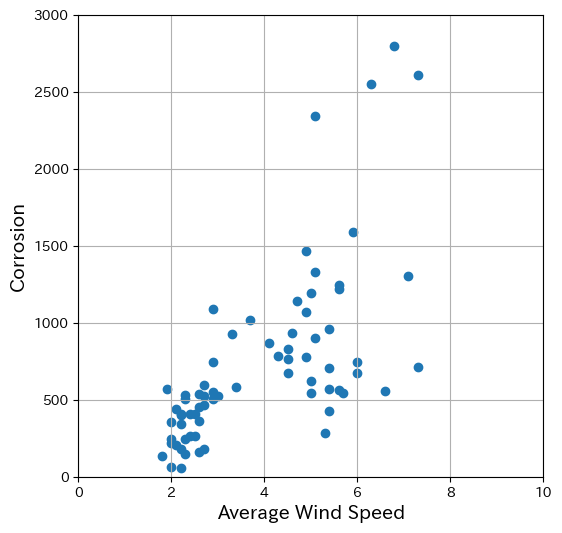

In [11]:
#腐食量と平均風速との相関図
fig, ax = plt.subplots(figsize=(6,6))

#着目する変数の指定（ここでは腐食量と平均風速）
X = df[['AW']]
y = df[['Corrosion']]

ax.scatter(X,y)

plt.xlabel("Average Wind Speed", fontsize =14)
plt.ylabel("Corrosion", fontsize =14)

# 横軸と縦軸のレンジの設定
plt.xlim(0, 10)
plt.ylim(0, 3000)

plt.grid()
plt.show()

### Scikit-Learnに慣れる：単回帰モデル

線形回帰モデルは、複数の入力変数（特徴量）と一つの出力変数（目的変数）の関係を、直線または平面（多次元の場合）で表現するものです。このモデルは、入力変数の変化に対して出力変数が線形に変化するという前提に基づいています。中でも、最も基本的な形が「単回帰」です。単回帰モデルは、一つの入力変数と一つの出力変数の関係を直線で表します。

本節では、Pythonの機械学習ライブラリであるscikit-learnを使用して、単回帰分析を実施する方法について詳しく解説します。単回帰分析の手順を学ぶことで、他の機械学習モデルの構成や分析手法にも応用できる基礎知識を身につけることができます。以下の①〜⑥のステップで進めます。

① Scikit-learnライブラリのインポート  
② 変数の指定  
③ 単回帰モデルの作成  
④ 出力変数の予測値の計算  
⑤ 予測値の可視化  
⑥ モデルの評価

#### ① Scikit-learnライブラリのインポート
Scikit-learnライブラリのlinear_modelモジュールから線形回帰モデルのためのクラスである`LinearRegression`クラスをインポートします。

In [12]:
# 線形回帰モデル
from sklearn.linear_model import LinearRegression

#### ② 変数の指定
scikit-learnでは、説明変数`X`は2次元の配列（DataFrame）として渡す必要があります。二重括弧`[[列名]]`を使うとDataFrame（2次元）になります。一方、目的変数`y`は1次元の配列（Series）として渡すのが標準です。一重括弧`[列名]`を使うとSeries（1次元）になります。

In [13]:
# 変数の定義
X = df[['AW']]      # 2次元DataFrame（scikit-learnはXに2次元を要求）
y = df['Corrosion']  # 1次元Series（yは1次元が標準）

#### ③ 単回帰モデルの作成

[1] **機械学習モデルの設定（インスタンス化）**：  
「インスタンス化」という言葉が分かりにくいという声をよく聞くので、噛み砕いて説明します。`LinearRegression`は、いわば「線形回帰モデルの設計図」です。プログラミングではこの設計図のことを**クラス**と呼びます。設計図（クラス）があるだけでは、実際にデータを学習させたり予測させたりすることはできません。設計図をもとに、実際に使える「実物」を1つ作る必要があります。この「設計図から実物を1つ作る」作業のことを**インスタンス化**と呼び、そうして作られた実物のことを**インスタンス**と呼びます。

たとえば、「車の設計図（クラス）」があっても、それだけでは走れません。設計図をもとに実際に1台組み立てて（インスタンス化して）はじめて、その車（インスタンス）に乗って走ることができます。コード上では、`model = LinearRegression()`の行が「設計図`LinearRegression`をもとに、`model`という名前で実物（インスタンス）を1つ作る」という処理にあたります。

[2] **モデルの訓練（フィッティング）**：  
次に、作成したインスタンスに`fit()`メソッドを適用し、与えられたデータを基に入力変数と出力変数の関係を最もよく説明する線形関数の係数を計算し、モデルをフィットさせます。このプロセスは「訓練（Training）」と呼ばれます。

以下の2行のコードで、機械学習モデルの設定と訓練が完了します。

In [14]:
#単回帰モデルの作成
model = LinearRegression()

#モデルの訓練（フィッティング）
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### ④ 出力変数の予測値の計算  
訓練済みの線形回帰モデルを使用して、入力データ`X`に基づいて予測値を計算するには、`predict()`メソッドを利用します。以下の例では、`model.predict(X)`によって入力データに対する予測された出力変数（目的変数）の値が計算され、その結果は`y_pred`という変数に格納されます。

In [15]:
y_pred = model.predict(X)

#### ⑤ 予測値の可視化（図6）
次に、④で予測された値（予測値）を可視化し、実際の腐食量と予測された腐食量を比較するためにプロットします。これにより、モデルの予測精度を視覚的に確認することができます。

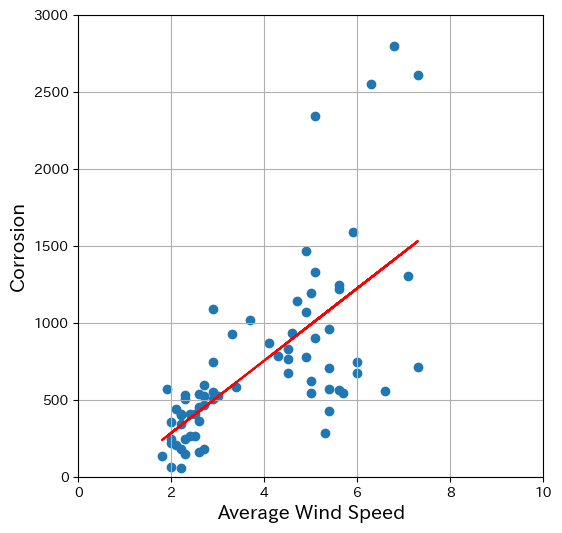

In [16]:
#腐食量と平均風速との関係図
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(X, y)
ax.plot(X, y_pred, linestyle="solid", color = "red")

plt.xlabel("Average Wind Speed", fontsize =14)
plt.ylabel("Corrosion", fontsize =14)

# 横軸のレンジを0から10に設定
plt.xlim(0, 10)
plt.ylim(0, 3000)

plt.grid()
plt.show()

#### ⑥　モデルの評価
モデルの性能を評価するために、いくつかの指標を用います。代表的な指標として、平均二乗誤差（MSE）、平均絶対誤差（MAE）、決定係数（R²スコア）などが挙げられます。

本ノートブックでは、決定係数と相関係数の2つに注目してモデルを評価します。決定係数は、モデルが実際のデータの変動をどれくらい説明できているかを示す指標です。一方、相関係数は、予測値と実際の値の間の線形な関係の強さと**方向**を表します。

決定係数は、一般的に0から1の値をとり、1に近いほどモデルの当てはまりが良いことを示します。また、相関係数は-1から1の値をとり、1に近ければ強い正の相関、-1に近ければ強い負の相関、0に近ければ相関がないことを示します。

> **注意（相関係数の計算方法）：** 相関係数を求める際、単純に`np.sqrt(R²)`（決定係数の平方根）としてしまうと、**常に0以上の値になり、負の相関を正の相関として表示してしまう**間違いが起こり得ます（単回帰では偶然`AW`とCorrosionの関係が正の相関なので数値上は影響が出ませんが、方法として正しくありません）。そこで、予測値と実測値から`np.corrcoef()`を使って直接、符号を保ったまま相関係数を計算します。

In [17]:
print('①　係数：', model.coef_[0])
print('②　切片：',model.intercept_)
print('③　決定係数 R^2： {:.3f}'.format(model.score(X, y)))

# 相関係数を予測値と実測値から直接計算（符号を保持するため）
correlation_coefficient = np.corrcoef(y.values, y_pred)[0, 1]
print('④　相関係数： {:.3f}'.format(correlation_coefficient))

①　係数： 234.70842014034844
②　切片： -184.51031519544392
③　決定係数 R^2： 0.442
④　相関係数： 0.665


【解説】  
① **係数**： `model.coef_` は線形回帰モデルの係数（回帰係数）を表します。この場合、`model.coef_[0]` は、最初の特徴量の係数を表示します。もし複数の特徴量がある場合は、`model.coef_` は配列で、各要素が対応する特徴量の係数になります。

② **切片**： `model.intercept_` は線形回帰モデルの切片（回帰直線がY軸と交わる点の値）を表示します。これは、すべての特徴量がゼロの場合の予測値です。

③ **決定係数**： `model.score(X, y)` はモデルの決定係数 \( R^2 \) を計算します。決定係数 \( R^2 \) は、モデルがどれだけデータの分散を説明できるかを示す指標で、1に近いほどモデルの説明力が高いことを意味します。決定係数の定義式は以下の通りです：

$$
R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}
$$

ここで、RSS（残差平方和）はモデルの予測と実際の値の差の平方和、TSS（全平方和）は実際の値とその平均値との差の平方和です。`{:.3f}` は、出力を小数点以下3桁にフォーマットして表示するための指定です。

④ **相関係数**： 相関係数は、実際の値と予測値との線形関係の強さと**方向**を示す指標です。値は −1 から 1 の範囲をとり、正の値なら正の相関、負の値なら負の相関を意味します。

$$
r = \frac{\sum (y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum (y_i - \bar{y})^2} \cdot \sqrt{\sum (\hat{y}_i - \bar{\hat{y}})^2}}
$$

ここで、`np.corrcoef(y, y_pred)[0, 1]` を使って実測値と予測値の組から直接計算します。単回帰では \( r^2 = R^2 \) が成り立ちますが、上記の通り\( r = \sqrt{R^2} \)とすると**符号の情報が失われる**ため、`np.corrcoef()`を使った計算が正確です。

---

# 4. まとめと演習問題

## まとめ

本ノートブックでは、次のことを学びました。

* 実際の研究データ（大気腐食データセット）を使って、住宅価格編と同じEDAの手順（概要統計・箱ひげ図・ペアプロット・相関係数・ヒートマップ・単回帰）が、題材を変えてもそのまま使えることを確認しました。
* `Corrosion`（腐食速度）の分布を、概要統計と箱ひげ図の両方で確認しました（図1）。
* `AW`（平均風速）と`Corrosion`の関係を単回帰でモデル化し、決定係数・相関係数で評価しました。

## 本ノートブックでは扱っていないこと（今後の課題）

1. **地点名（Place）は説明変数として使っていません。** インデックスとして保持されているだけです。次のノートブック（`Scikit-learn-4_ML.ipynb`）で、この点がモデルの汎化性能の解釈にどう影響するかを詳しく見ます。
2. **`Month`の周期性（季節性）は明示的にモデル化していません。** 単純に列を削除しています。
3. **train/testの分割をしていません。** 単回帰の評価は学習に使ったデータそのもので行っています。この限界は、住宅価格編（Part 1）と同じです。

## 演習問題

1. `Corrosion`以外の変数（例：`Hum`＝平均湿度）についても箱ひげ図を作成し、`Corrosion`の箱ひげ図と分布の形（対称か、歪んでいるか）を比較してみましょう。
2. ヒートマップ（図の④）を見て、`Corrosion`ともっとも相関が強い変数はどれか確認し、その変数を使って`AW`の代わりに単回帰モデルを作り直してみましょう。決定係数は`AW`を使った場合より高くなりますか。
3. 6地点（`df.index.unique()`で確認できます）ごとに`Corrosion`の平均値を比較してみましょう（ヒント：`df.groupby(df.index)['Corrosion'].mean()`）。地点による差はどれくらいありますか。